# Clean Maven Market - Daily Retail Revenue Analysis

Notebook này xử lý dataset **Maven Market Datasets** theo hướng Data Science cho bài toán:

```text
date + store_id -> net_daily_revenue
```

Maven Market là dataset dạng star schema gồm transaction, product, store, region, customer, calendar và returns. Notebook sẽ:

1. Đọc và kiểm tra các bảng gốc.
2. Join transaction với product, store, region, customer.
3. Tính `gross_revenue`, `gross_profit`, `return_value`, `net_revenue`.
4. Aggregate về cấp ngày-cửa hàng.
5. Phân tích data quality, bias, variation, revenue distribution, store/country effect, product/brand effect, return effect.
6. Chốt feature nào dùng được và feature nào có nguy cơ leakage.

Lưu ý quan trọng:

```text
net_revenue = gross_revenue - return_value
```

Trong Maven, doanh thu không có sẵn trực tiếp trong transaction, mà được tính bằng:

```text
gross_revenue = quantity * product_retail_price
```

## Cell 1 - Import thư viện và khai báo đường dẫn

Cell này chuẩn bị môi trường, tìm `PROJECT_ROOT`, và khai báo đường dẫn đến các file CSV Maven Market.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd
for candidate in [cwd, *cwd.parents]:
    if (candidate / "data" / "Maven Market Datasets").exists():
        PROJECT_ROOT = candidate
        break

DATA_DIR = PROJECT_ROOT / "data" / "Maven Market Datasets"

CALENDAR_PATH = DATA_DIR / "MavenMarket_Calendar.csv"
CUSTOMERS_PATH = DATA_DIR / "MavenMarket_Customers.csv"
PRODUCTS_PATH = DATA_DIR / "MavenMarket_Products.csv"
REGIONS_PATH = DATA_DIR / "MavenMarket_Regions.csv"
RETURNS_PATH = DATA_DIR / "MavenMarket_Returns_1997-1998.csv"
STORES_PATH = DATA_DIR / "MavenMarket_Stores.csv"
TXN_1997_PATH = DATA_DIR / "MavenMarket_Transactions_1997.csv"
TXN_1998_PATH = DATA_DIR / "MavenMarket_Transactions_1998.csv"

for name, path in {
    "calendar": CALENDAR_PATH,
    "customers": CUSTOMERS_PATH,
    "products": PRODUCTS_PATH,
    "regions": REGIONS_PATH,
    "returns": RETURNS_PATH,
    "stores": STORES_PATH,
    "transactions_1997": TXN_1997_PATH,
    "transactions_1998": TXN_1998_PATH,
}.items():
    print(f"{name}: {path.exists()} - {path}")

calendar: True - /Users/tnhatnguyendev2805/Documents/University/Data Science/Final Project/data/Maven Market Datasets/MavenMarket_Calendar.csv
customers: True - /Users/tnhatnguyendev2805/Documents/University/Data Science/Final Project/data/Maven Market Datasets/MavenMarket_Customers.csv
products: True - /Users/tnhatnguyendev2805/Documents/University/Data Science/Final Project/data/Maven Market Datasets/MavenMarket_Products.csv
regions: True - /Users/tnhatnguyendev2805/Documents/University/Data Science/Final Project/data/Maven Market Datasets/MavenMarket_Regions.csv
returns: True - /Users/tnhatnguyendev2805/Documents/University/Data Science/Final Project/data/Maven Market Datasets/MavenMarket_Returns_1997-1998.csv
stores: True - /Users/tnhatnguyendev2805/Documents/University/Data Science/Final Project/data/Maven Market Datasets/MavenMarket_Stores.csv
transactions_1997: True - /Users/tnhatnguyendev2805/Documents/University/Data Science/Final Project/data/Maven Market Datasets/MavenMarket

## Cell 2 - Đọc dữ liệu gốc và thống kê schema

Cell này đọc toàn bộ các bảng Maven. Vì dataset không quá lớn, ta có thể join trực tiếp.

In [2]:
calendar_raw = pd.read_csv(CALENDAR_PATH)
customers_raw = pd.read_csv(CUSTOMERS_PATH)
products_raw = pd.read_csv(PRODUCTS_PATH)
regions_raw = pd.read_csv(REGIONS_PATH)
returns_raw = pd.read_csv(RETURNS_PATH)
stores_raw = pd.read_csv(STORES_PATH)
txn_1997 = pd.read_csv(TXN_1997_PATH)
txn_1998 = pd.read_csv(TXN_1998_PATH)

raw_tables = {
    "calendar": calendar_raw,
    "customers": customers_raw,
    "products": products_raw,
    "regions": regions_raw,
    "returns": returns_raw,
    "stores": stores_raw,
    "txn_1997": txn_1997,
    "txn_1998": txn_1998,
}

overview = []
for name, df in raw_tables.items():
    print()
    print(f"{name} columns:")
    print(list(df.columns))
    display(df.head(3))


calendar columns:
['date']


,date
0,1/1/1997
1,1/2/1997
2,1/3/1997



customers columns:
['customer_id', 'customer_acct_num', 'first_name', 'last_name', 'customer_address', 'customer_city', 'customer_state_province', 'customer_postal_code', 'customer_country', 'birthdate', 'marital_status', 'yearly_income', 'gender', 'total_children', 'num_children_at_home', 'education', 'acct_open_date', 'member_card', 'occupation', 'homeowner']


,customer_id,customer_acct_num,first_name,last_name,customer_address,customer_city,customer_state_province,customer_postal_code,customer_country,birthdate,marital_status,yearly_income,gender,total_children,num_children_at_home,education,acct_open_date,member_card,occupation,homeowner
0,1,87462024688,Sheri,Nowmer,2433 Bailey Road,Tlaxiaco,Oaxaca,15057,Mexico,8/26/1961,M,$30K - $50K,F,4,2,Partial High School,9/10/1991,Bronze,Skilled Manual,Y
1,2,87470586299,Derrick,Whelply,2219 Dewing Avenue,Sooke,BC,17172,Canada,7/3/1915,S,$70K - $90K,M,1,0,Partial High School,3/11/1993,Bronze,Professional,N
2,3,87475757600,Jeanne,Derry,7640 First Ave.,Issaquah,WA,73980,USA,6/21/1910,M,$50K - $70K,F,1,1,Bachelors Degree,6/11/1991,Bronze,Professional,Y



products columns:
['product_id', 'product_brand', 'product_name', 'product_sku', 'product_retail_price', 'product_cost', 'product_weight', 'recyclable', 'low_fat']


...

,store_id,region_id,store_type,store_name,store_street_address,store_city,store_state,store_country,store_phone,first_opened_date,last_remodel_date,total_sqft,grocery_sqft
0,1,28,Supermarket,Store 1,2853 Bailey Rd,Acapulco,Guerrero,Mexico,262-555-5124,1/9/1982,12/5/1990,23593,17475
1,2,78,Small Grocery,Store 2,5203 Catanzaro Way,Bellingham,WA,USA,605-555-8203,4/2/1970,6/4/1973,28206,22271
2,3,76,Supermarket,Store 3,1501 Ramsey Circle,Bremerton,WA,USA,509-555-1596,6/14/1959,11/19/1967,39696,24390



txn_1997 columns:
['transaction_date', 'stock_date', 'product_id', 'customer_id', 'store_id', 'quantity']


,transaction_date,stock_date,product_id,customer_id,store_id,quantity
0,1/1/1997,12/31/1996,869,3449,6,5
1,1/1/1997,12/31/1996,1472,3449,6,3
2,1/1/1997,12/28/1996,76,3449,6,4



txn_1998 columns:
['transaction_date', 'stock_date', 'product_id', 'customer_id', 'store_id', 'quantity']


,transaction_date,stock_date,product_id,customer_id,store_id,quantity
0,1/1/1998,12/25/1997,4,2439,10,3
1,1/1/1998,12/28/1997,11,4284,10,3
2,1/1/1998,12/28/1997,12,534,10,3


## Cell 3 - Parse date và tạo calendar features

Cell này tạo các biến thời gian từ `calendar`. Đây là nhóm feature an toàn vì biết trước khi dự đoán doanh thu.

In [3]:
calendar = calendar_raw.copy()
calendar["date"] = pd.to_datetime(calendar["date"])
calendar["year"] = calendar["date"].dt.year.astype("int16")
calendar["month"] = calendar["date"].dt.month.astype("int8")
calendar["quarter"] = calendar["date"].dt.quarter.astype("int8")
calendar["week_of_year"] = calendar["date"].dt.isocalendar().week.astype("int16")
calendar["day_of_month"] = calendar["date"].dt.day.astype("int8")
calendar["day_of_year"] = calendar["date"].dt.dayofyear.astype("int16")
calendar["day_of_week"] = calendar["date"].dt.day_name()
calendar["day_of_week_num"] = calendar["date"].dt.dayofweek.astype("int8")
calendar["is_weekend"] = calendar["day_of_week_num"].isin([5, 6]).astype("int8")
calendar["year_month"] = calendar["date"].dt.to_period("M").astype(str)

print("calendar shape:", calendar.shape)
print("date range:", calendar["date"].min(), "->", calendar["date"].max())
display(calendar.head())

calendar shape: (730, 11)
date range: 1997-01-01 00:00:00 -> 1998-12-31 00:00:00


,date,year,month,quarter,week_of_year,day_of_month,day_of_year,day_of_week,day_of_week_num,is_weekend,year_month
0,1997-01-01,1997,1,1,1,1,1,Wednesday,2,0,1997-01
1,1997-01-02,1997,1,1,1,2,2,Thursday,3,0,1997-01
2,1997-01-03,1997,1,1,1,3,3,Friday,4,0,1997-01
3,1997-01-04,1997,1,1,1,4,4,Saturday,5,1,1997-01
4,1997-01-05,1997,1,1,1,5,5,Sunday,6,1,1997-01


## Cell 4 - Làm sạch dimension tables

Cell này chuẩn hóa product/store/region/customer để join. Các biến như `store_type`, `store_country`, `total_sqft`, `grocery_sqft` là feature store-level có thể dùng trước khi dự đoán.

In [4]:
products = products_raw.copy()
products["recyclable"] = products["recyclable"].fillna(0).astype("int8")
products["low_fat"] = products["low_fat"].fillna(0).astype("int8")
products["gross_margin_per_unit"] = products["product_retail_price"] - products["product_cost"]
products["gross_margin_pct"] = np.where(
    products["product_retail_price"].gt(0),
    products["gross_margin_per_unit"] / products["product_retail_price"],
    np.nan,
)

regions = regions_raw.copy()

stores = stores_raw.copy()
stores["first_opened_date"] = pd.to_datetime(stores["first_opened_date"])
stores["last_remodel_date"] = pd.to_datetime(stores["last_remodel_date"])
stores["grocery_sqft_ratio"] = stores["grocery_sqft"] / stores["total_sqft"]
stores = stores.merge(regions, on="region_id", how="left", validate="many_to_one")

customers = customers_raw.copy()
customers["birthdate"] = pd.to_datetime(customers["birthdate"], errors="coerce")
customers["acct_open_date"] = pd.to_datetime(customers["acct_open_date"], errors="coerce")
customers["last_name"] = customers["last_name"].fillna("Unknown")

print("products:", products.shape, "unique brands:", products["product_brand"].nunique())
print("stores:", stores.shape, "countries:", stores["store_country"].nunique())
print("customers:", customers.shape)

display(products.head())
display(stores.head())
display(customers.head())

products: (1560, 11) unique brands: 111
stores: (24, 16) countries: 3
customers: (10281, 20)


,product_id,product_brand,product_name,product_sku,product_retail_price,product_cost,product_weight,recyclable,low_fat,gross_margin_per_unit,gross_margin_pct
0,1,Washington,Washington Berry Juice,90748583674,2.850,0.940,8.390,0,0,1.910,0.670
1,2,Washington,Washington Mango Drink,96516502499,0.740,0.260,7.420,0,1,0.480,0.649
2,3,Washington,Washington Strawberry Drink,58427771925,0.830,0.400,13.100,1,1,0.430,0.518
3,4,Washington,Washington Cream Soda,64412155747,3.640,1.640,10.600,1,0,2.000,0.549
4,5,Washington,Washington Diet Soda,85561191439,2.190,0.770,6.660,1,0,1.420,0.648


,store_id,region_id,store_type,store_name,store_street_address,store_city,store_state,store_country,store_phone,first_opened_date,last_remodel_date,total_sqft,grocery_sqft,grocery_sqft_ratio,sales_district,sales_region
0,1,28,Supermarket,Store 1,2853 Bailey Rd,Acapulco,Guerrero,Mexico,262-555-5124,1982-01-09,1990-12-05,23593,17475,0.741,Acapulco,Mexico West
1,2,78,Small Grocery,Store 2,5203 Catanzaro Way,Bellingham,WA,USA,605-555-8203,1970-04-02,1973-06-04,28206,22271,0.790,Bellingham,North West
2,3,76,Supermarket,Store 3,1501 Ramsey Circle,Bremerton,WA,USA,509-555-1596,1959-06-14,1967-11-19,39696,24390,0.614,Bremerton,North West
3,4,27,Gourmet Supermarket,Store 4,433 St George Dr,Camacho,Zacatecas,Mexico,304-555-1474,1994-09-27,1995-12-01,23759,16844,0.709,Camacho,Mexico Central
4,5,4,Small Grocery,Store 5,1250 Coggins Drive,Guadalajara,Jalisco,Mexico,801-555-4324,1978-09-18,1991-06-29,24597,15012,0.610,Guadalajara,Mexico West


,customer_id,customer_acct_num,first_name,last_name,customer_address,customer_city,customer_state_province,customer_postal_code,customer_country,birthdate,marital_status,yearly_income,gender,total_children,num_children_at_home,education,acct_open_date,member_card,occupation,homeowner
0,1,87462024688,Sheri,Nowmer,2433 Bailey Road,Tlaxiaco,Oaxaca,15057,Mexico,1961-08-26,M,$30K - $50K,F,4,2,Partial High School,1991-09-10,Bronze,Skilled Manual,Y
1,2,87470586299,Derrick,Whelply,2219 Dewing Avenue,Sooke,BC,17172,Canada,1915-07-03,S,$70K - $90K,M,1,0,Partial High School,1993-03-11,Bronze,Professional,N
2,3,87475757600,Jeanne,Derry,7640 First Ave.,Issaquah,WA,73980,USA,1910-06-21,M,$50K - $70K,F,1,1,Bachelors Degree,1991-06-11,Bronze,Professional,Y
3,4,87500482201,Michael,Spence,337 Tosca Way,Burnaby,BC,74674,Canada,1969-06-20,M,$10K - $30K,M,4,4,Partial High School,1994-05-21,Normal,Skilled Manual,N
4,5,87514054179,Maya,Gutierrez,8668 Via Neruda,Novato,CA,57355,USA,1951-05-10,S,$30K - $50K,F,3,0,Partial College,1992-08-21,Silver,Manual,N


## Cell 5 - Gộp transactions 1997 và 1998

Cell này nối hai file transaction thành một bảng duy nhất. Mỗi dòng là một line item bán hàng.

In [5]:
txn_1997 = txn_1997.copy()
txn_1998 = txn_1998.copy()
txn_1997["source_year_file"] = 1997
txn_1998["source_year_file"] = 1998

transactions = pd.concat([txn_1997, txn_1998], ignore_index=True)
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
transactions["stock_date"] = pd.to_datetime(transactions["stock_date"])

print("transactions shape:", transactions.shape)
print("transaction date range:", transactions["transaction_date"].min(), "->", transactions["transaction_date"].max())
print("stores by year:")
display(transactions.assign(year=transactions["transaction_date"].dt.year).groupby("year")["store_id"].nunique().reset_index(name="store_count"))
display(transactions.head())

transactions shape: (269720, 7)
transaction date range: 1997-01-01 00:00:00 -> 1998-12-30 00:00:00
stores by year:


,year,store_count
0,1997,13
1,1998,24


,transaction_date,stock_date,product_id,customer_id,store_id,quantity,source_year_file
0,1997-01-01,1996-12-31,869,3449,6,5,1997
1,1997-01-01,1996-12-31,1472,3449,6,3,1997
2,1997-01-01,1996-12-28,76,3449,6,4,1997
3,1997-01-01,1996-12-26,320,3449,6,3,1997
4,1997-01-01,1996-12-25,4,3449,6,4,1997


## Cell 6 - Join transactions với product, store, region, customer

Cell này tạo bảng line item hoàn chỉnh. Sau join, mỗi dòng có thông tin sản phẩm, cửa hàng, vùng bán hàng và khách hàng.

In [6]:
line_items = transactions.merge(
    products,
    on="product_id",
    how="left",
    validate="many_to_one",
)
line_items = line_items.merge(
    stores,
    on="store_id",
    how="left",
    validate="many_to_one",
)
line_items = line_items.merge(
    customers,
    on="customer_id",
    how="left",
    validate="many_to_one",
)

line_items["gross_revenue"] = line_items["quantity"] * line_items["product_retail_price"]
line_items["gross_cost"] = line_items["quantity"] * line_items["product_cost"]
line_items["gross_profit"] = line_items["gross_revenue"] - line_items["gross_cost"]
line_items["gross_margin_pct_line"] = np.where(
    line_items["gross_revenue"].gt(0),
    line_items["gross_profit"] / line_items["gross_revenue"],
    np.nan,
)
line_items["customer_age"] = (line_items["transaction_date"] - line_items["birthdate"]).dt.days / 365.25
line_items["customer_account_age_days"] = (line_items["transaction_date"] - line_items["acct_open_date"]).dt.days
line_items["store_age_years"] = (line_items["transaction_date"] - line_items["first_opened_date"]).dt.days / 365.25
line_items["days_since_remodel"] = (line_items["transaction_date"] - line_items["last_remodel_date"]).dt.days

join_quality = pd.DataFrame(
    [
        ("rows", len(line_items)),
        ("missing_product_rows", int(line_items["product_brand"].isna().sum())),
        ("missing_store_rows", int(line_items["store_name"].isna().sum())),
        ("missing_region_rows", int(line_items["sales_region"].isna().sum())),
        ("missing_customer_rows", int(line_items["first_name"].isna().sum())),
        ("negative_revenue_rows", int(line_items["gross_revenue"].lt(0).sum())),
        ("zero_revenue_rows", int(line_items["gross_revenue"].eq(0).sum())),
    ],
    columns=["metric", "value"],
)

display(join_quality)
display(line_items.head())

,metric,value
0,rows,269720
1,missing_product_rows,0
2,missing_store_rows,0
3,missing_region_rows,0
4,missing_customer_rows,0
5,negative_revenue_rows,0
6,zero_revenue_rows,0


,transaction_date,stock_date,product_id,customer_id,store_id,quantity,source_year_file,product_brand,product_name,product_sku,product_retail_price,product_cost,product_weight,recyclable,low_fat,gross_margin_per_unit,gross_margin_pct,region_id,store_type,store_name,store_street_address,store_city,store_state,store_country,store_phone,first_opened_date,last_remodel_date,total_sqft,grocery_sqft,grocery_sqft_ratio,sales_district,sales_region,customer_acct_num,first_name,last_name,customer_address,customer_city,customer_state_province,customer_postal_code,customer_country,birthdate,marital_status,yearly_income,gender,total_children,num_children_at_home,education,acct_open_date,member_card,occupation,homeowner,gross_revenue,gross_cost,gross_profit,gross_margin_pct_line,customer_age,customer_account_age_days,store_age_years,days_since_remodel
0,1997-01-01,1996-12-31,869,3449,6,5,1997,Nationeel,Nationeel Grape Fruit Roll,52382137179,2.120,0.910,17.000,1,0,1.210,0.571,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1981-01-03,1991-03-13,23688,15337,0.647,Los Angeles,South West,27508307099,Lana,Weis,9648 Maureen Circle,Pomona,CA,16093,USA,1979-11-26,M,$30K - $50K,F,2,0,High School Degree,1994-12-07,Bronze,Skilled Manual,Y,10.600,4.550,6.050,0.571,17.101,756,15.995,2121
1,1997-01-01,1996-12-31,1472,3449,6,3,1997,Fort West,Fort West Fudge Cookies,37276054024,2.200,0.900,8.280,1,0,1.300,0.591,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1981-01-03,1991-03-13,23688,15337,0.647,Los Angeles,South West,27508307099,Lana,Weis,9648 Maureen Circle,Pomona,CA,16093,USA,1979-11-26,M,$30K - $50K,F,2,0,High School Degree,1994-12-07,Bronze,Skilled Manual,Y,6.600,2.700,3.900,0.591,17.101,756,15.995,2121
2,1997-01-01,1996-12-28,76,3449,6,4,1997,Red Spade,Red Spade Sliced Chicken,62054644227,1.690,0.690,18.100,0,1,1.000,0.592,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1981-01-03,1991-03-13,23688,15337,0.647,Los Angeles,South West,27508307099,Lana,Weis,9648 Maureen Circle,Pomona,CA,16093,USA,1979-11-26,M,$30K - $50K,F,2,0,High School Degree,1994-12-07,Bronze,Skilled Manual,Y,6.760,2.760,4.000,0.592,17.101,756,15.995,2121
3,1997-01-01,1996-12-26,320,3449,6,3,1997,Excellent,Excellent Cranberry Juice,36570182442,3.260,1.080,16.400,0,0,2.180,0.669,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1981-01-03,1991-03-13,23688,15337,0.647,Los Angeles,South West,27508307099,Lana,Weis,9648 Maureen Circle,Pomona,CA,16093,USA,1979-11-26,M,$30K - $50K,F,2,0,High School Degree,1994-12-07,Bronze,Skilled Manual,Y,9.780,3.240,6.540,0.669,17.101,756,15.995,2121
4,1997-01-01,1996-12-25,4,3449,6,4,1997,Washington,Washington Cream Soda,64412155747,3.640,1.640,10.600,1,0,2.000,0.549,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1981-01-03,1991-03-13,23688,15337,0.647,Los Angeles,South West,27508307099,Lana,Weis,9648 Maureen Circle,Pomona,CA,16093,USA,1979-11-26,M,$30K - $50K,F,2,0,High School Degree,1994-12-07,Bronze,Skilled Manual,Y,14.560,6.560,8.000,0.549,17.101,756,15.995,2121


## Cell 7 - Xử lý returns và tính return value

Returns không nối trực tiếp với transaction cụ thể, nên ta tính return value theo `return_date + store_id + product/brand` bằng `quantity * product_retail_price`.

In [7]:
returns = returns_raw.copy()
returns["return_date"] = pd.to_datetime(returns["return_date"])
returns = returns.merge(products, on="product_id", how="left", validate="many_to_one")
returns = returns.merge(stores, on="store_id", how="left", validate="many_to_one")
returns["return_value"] = returns["quantity"] * returns["product_retail_price"]
returns["return_cost"] = returns["quantity"] * returns["product_cost"]

return_quality = pd.DataFrame(
    [
        ("rows", len(returns)),
        ("missing_product_rows", int(returns["product_brand"].isna().sum())),
        ("missing_store_rows", int(returns["store_name"].isna().sum())),
        ("negative_return_value_rows", int(returns["return_value"].lt(0).sum())),
    ],
    columns=["metric", "value"],
)

display(return_quality)
display(returns.head())

,metric,value
0,rows,7087
1,missing_product_rows,0
2,missing_store_rows,0
3,negative_return_value_rows,0


,return_date,product_id,store_id,quantity,product_brand,product_name,product_sku,product_retail_price,product_cost,product_weight,recyclable,low_fat,gross_margin_per_unit,gross_margin_pct,region_id,store_type,store_name,store_street_address,store_city,store_state,store_country,store_phone,first_opened_date,last_remodel_date,total_sqft,grocery_sqft,grocery_sqft_ratio,sales_district,sales_region,return_value,return_cost
0,1997-01-01,250,6,1,Best Choice,Best Choice Golden Raisins,95335729718,2.590,0.830,13.400,0,0,1.760,0.680,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1981-01-03,1991-03-13,23688,15337,0.647,Los Angeles,South West,2.590,0.830
1,1997-01-01,628,6,1,Token,Token Cola,48011456131,1.400,0.520,16.400,1,0,0.880,0.629,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1981-01-03,1991-03-13,23688,15337,0.647,Los Angeles,South West,1.400,0.520
2,1997-01-01,869,6,1,Nationeel,Nationeel Grape Fruit Roll,52382137179,2.120,0.910,17.000,1,0,1.210,0.571,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1981-01-03,1991-03-13,23688,15337,0.647,Los Angeles,South West,2.120,0.910
3,1997-01-02,469,11,1,Red Wing,Red Wing Silver Cleaner,87961875796,1.290,0.580,8.030,1,0,0.710,0.550,22,Supermarket,Store 11,5371 Holland Circle,Portland,OR,USA,685-555-8995,1976-09-17,1982-05-15,20319,16232,0.799,Portland,North West,1.290,0.580
4,1997-01-02,532,23,2,Fast,Fast Sugar Cookies,56197987198,3.870,1.390,21.700,1,0,2.480,0.641,89,Mid-Size Grocery,Store 23,3920 Noah Court,Yakima,WA,USA,170-555-8424,1977-07-16,1987-07-24,29182,19283,0.661,Yakima,North West,7.740,2.780


## Cell 8 - Aggregate sales và returns theo ngày-cửa hàng

Cell này tạo target chính của Maven:

```text
date + store_id -> gross_revenue, return_value, net_revenue
```

Đây là grain phù hợp nhất để so sánh với scope `daily revenue` giữa các dataset.

In [8]:
sales_store_daily = (
    line_items.groupby(["transaction_date", "store_id"], as_index=False)
    .agg(
        gross_revenue=("gross_revenue", "sum"),
        gross_cost=("gross_cost", "sum"),
        gross_profit=("gross_profit", "sum"),
        quantity_sold=("quantity", "sum"),
        line_item_count=("product_id", "size"),
        distinct_products_sold=("product_id", "nunique"),
        distinct_brands_sold=("product_brand", "nunique"),
        distinct_customers=("customer_id", "nunique"),
        avg_customer_age=("customer_age", "mean"),
        avg_unit_retail_price=("product_retail_price", "mean"),
        avg_margin_pct_line=("gross_margin_pct_line", "mean"),
    )
    .rename(columns={"transaction_date": "date"})
)

returns_store_daily = (
    returns.groupby(["return_date", "store_id"], as_index=False)
    .agg(
        return_quantity=("quantity", "sum"),
        return_value=("return_value", "sum"),
        return_cost=("return_cost", "sum"),
        returned_product_count=("product_id", "nunique"),
    )
    .rename(columns={"return_date": "date"})
)

print("sales_store_daily shape:", sales_store_daily.shape)
print("returns_store_daily shape:", returns_store_daily.shape)
display(sales_store_daily.head())
display(returns_store_daily.head())

sales_store_daily shape: (2220, 13)
returns_store_daily shape: (1704, 6)


,date,store_id,gross_revenue,gross_cost,gross_profit,quantity_sold,line_item_count,distinct_products_sold,distinct_brands_sold,distinct_customers,avg_customer_age,avg_unit_retail_price,avg_margin_pct_line
0,1997-01-01,6,659.430,268.680,390.750,324,99,99,49,22,51.463,1.991,0.592
1,1997-01-01,14,46.910,19.500,27.410,24,18,18,15,4,30.778,2.008,0.590
2,1997-01-02,11,882.940,347.240,535.700,431,140,135,61,32,50.173,2.066,0.608
3,1997-01-02,23,421.590,173.920,247.670,204,66,64,41,14,55.514,2.032,0.587
4,1997-01-03,7,867.640,354.080,513.560,394,128,124,58,30,54.559,2.186,0.595


,date,store_id,return_quantity,return_value,return_cost,returned_product_count
0,1997-01-01,6,3,6.110,2.260,3
1,1997-01-02,11,3,5.640,2.250,3
2,1997-01-02,23,3,10.210,3.570,2
3,1997-01-03,7,5,15.260,5.600,4
4,1997-01-03,23,2,3.300,1.560,1


## Cell 9 - Tạo grid ngày-cửa hàng theo giai đoạn store có dữ liệu quan sát

Không nên tạo zero cho toàn bộ 24 stores từ 1997 nếu store đó chưa xuất hiện trong transaction file. Cell này dùng `first_observed_transaction_date` để tạo grid hợp lý hơn.

In [9]:
store_observed_period = (
    transactions.groupby("store_id", as_index=False)
    .agg(
        first_observed_transaction_date=("transaction_date", "min"),
        last_observed_transaction_date=("transaction_date", "max"),
        observed_transaction_rows=("transaction_date", "size"),
    )
)

store_grid_base = stores.merge(store_observed_period, on="store_id", how="left")
max_calendar_date = calendar["date"].max()

grid_parts = []
for _, row in store_grid_base.dropna(subset=["first_observed_transaction_date"]).iterrows():
    dates = calendar.loc[
        (calendar["date"] >= row["first_observed_transaction_date"]) &
        (calendar["date"] <= max_calendar_date),
        ["date", "year", "month", "quarter", "week_of_year", "day_of_month", "day_of_year", "year_month", "day_of_week", "day_of_week_num", "is_weekend"],
    ].copy()
    for col in ["store_id", "region_id", "store_type", "store_name", "store_city", "store_state", "store_country", "sales_district", "sales_region", "total_sqft", "grocery_sqft", "grocery_sqft_ratio", "first_opened_date", "last_remodel_date", "first_observed_transaction_date", "last_observed_transaction_date"]:
        dates[col] = row[col]
    grid_parts.append(dates)

store_date_grid = pd.concat(grid_parts, ignore_index=True)
store_date_grid["store_age_years"] = (store_date_grid["date"] - store_date_grid["first_opened_date"]).dt.days / 365.25
store_date_grid["days_since_remodel"] = (store_date_grid["date"] - store_date_grid["last_remodel_date"]).dt.days

print("store_date_grid shape:", store_date_grid.shape)
display(store_observed_period.sort_values("store_id"))
display(store_date_grid.head())

store_date_grid shape: (13388, 29)


,store_id,first_observed_transaction_date,last_observed_transaction_date,observed_transaction_rows
0,1,1998-01-12,1998-12-20,8473
1,2,1997-01-05,1998-12-25,2769
2,3,1997-01-06,1998-12-25,16598
3,4,1998-01-02,1998-12-29,8267
4,5,1998-01-02,1998-12-22,1470
5,6,1997-01-01,1998-12-28,14775
6,7,1997-01-03,1998-12-20,16726
7,8,1998-01-04,1998-12-24,13014
8,9,1998-01-09,1998-12-23,3817
9,10,1998-01-01,1998-12-30,8744


,date,year,month,quarter,week_of_year,day_of_month,day_of_year,year_month,day_of_week,day_of_week_num,is_weekend,store_id,region_id,store_type,store_name,store_city,store_state,store_country,sales_district,sales_region,total_sqft,grocery_sqft,grocery_sqft_ratio,first_opened_date,last_remodel_date,first_observed_transaction_date,last_observed_transaction_date,store_age_years,days_since_remodel
0,1998-01-12,1998,1,1,3,12,12,1998-01,Monday,0,0,1,28,Supermarket,Store 1,Acapulco,Guerrero,Mexico,Acapulco,Mexico West,23593,17475,0.741,1982-01-09,1990-12-05,1998-01-12,1998-12-20,16.008,2595
1,1998-01-13,1998,1,1,3,13,13,1998-01,Tuesday,1,0,1,28,Supermarket,Store 1,Acapulco,Guerrero,Mexico,Acapulco,Mexico West,23593,17475,0.741,1982-01-09,1990-12-05,1998-01-12,1998-12-20,16.011,2596
2,1998-01-14,1998,1,1,3,14,14,1998-01,Wednesday,2,0,1,28,Supermarket,Store 1,Acapulco,Guerrero,Mexico,Acapulco,Mexico West,23593,17475,0.741,1982-01-09,1990-12-05,1998-01-12,1998-12-20,16.014,2597
3,1998-01-15,1998,1,1,3,15,15,1998-01,Thursday,3,0,1,28,Supermarket,Store 1,Acapulco,Guerrero,Mexico,Acapulco,Mexico West,23593,17475,0.741,1982-01-09,1990-12-05,1998-01-12,1998-12-20,16.016,2598
4,1998-01-16,1998,1,1,3,16,16,1998-01,Friday,4,0,1,28,Supermarket,Store 1,Acapulco,Guerrero,Mexico,Acapulco,Mexico West,23593,17475,0.741,1982-01-09,1990-12-05,1998-01-12,1998-12-20,16.019,2599


## Cell 10 - Tạo bảng Maven daily clean

Sau khi chạy thử panel đầy đủ `date x store`, ta thấy Maven rất thưa nếu lấp zero cho mọi ngày-cửa hàng. Điều này khác M5 và có thể tạo **false zero**: store-day không xuất hiện trong transaction chưa chắc là doanh thu thật bằng 0.

Vì vậy cell này tạo hai bảng:

- `maven_store_daily_panel`: panel đầy đủ theo observed period, dùng để kiểm tra coverage/selection bias.
- `maven_store_daily`: bảng chính cho EDA/modeling ban đầu, chỉ gồm store-day có hoạt động bán hàng hoặc trả hàng quan sát được.

Target chính:

```text
date + store_id -> net_revenue
```

In [10]:
# 1) Panel đầy đủ để kiểm tra sparsity/coverage, không dùng làm bảng chính nếu zero quá nhiều.
maven_store_daily_panel = store_date_grid.merge(
    sales_store_daily,
    on=["date", "store_id"],
    how="left",
    validate="one_to_one",
)
maven_store_daily_panel = maven_store_daily_panel.merge(
    returns_store_daily,
    on=["date", "store_id"],
    how="left",
    validate="one_to_one",
)

panel_zero_fill_cols = [
    "gross_revenue", "gross_cost", "gross_profit", "quantity_sold", "line_item_count",
    "distinct_products_sold", "distinct_brands_sold", "distinct_customers",
    "return_quantity", "return_value", "return_cost", "returned_product_count",
]
for col in panel_zero_fill_cols:
    maven_store_daily_panel[col] = maven_store_daily_panel[col].fillna(0)

maven_store_daily_panel["net_revenue"] = maven_store_daily_panel["gross_revenue"] - maven_store_daily_panel["return_value"]
maven_store_daily_panel["has_sales"] = maven_store_daily_panel["gross_revenue"].gt(0).astype("int8")
maven_store_daily_panel["has_returns"] = maven_store_daily_panel["return_value"].gt(0).astype("int8")

panel_sparsity = pd.DataFrame(
    [
        ("panel_rows", len(maven_store_daily_panel)),
        ("panel_zero_gross_revenue_rows", int(maven_store_daily_panel["gross_revenue"].eq(0).sum())),
        ("panel_zero_gross_revenue_pct", maven_store_daily_panel["gross_revenue"].eq(0).mean() * 100),
        ("panel_active_store_day_rows", int(maven_store_daily_panel["has_sales"].sum())),
        ("panel_return_only_rows", int((maven_store_daily_panel["has_sales"].eq(0) & maven_store_daily_panel["has_returns"].eq(1)).sum())),
    ],
    columns=["metric", "value"],
)

# 2) Bảng observed activity days: có sales hoặc có returns.
maven_store_daily_observed = sales_store_daily.merge(
    returns_store_daily,
    on=["date", "store_id"],
    how="outer",
    validate="one_to_one",
)

sales_metric_cols = [
    "gross_revenue", "gross_cost", "gross_profit", "quantity_sold", "line_item_count",
    "distinct_products_sold", "distinct_brands_sold", "distinct_customers",
]
return_metric_cols = ["return_quantity", "return_value", "return_cost", "returned_product_count"]
for col in sales_metric_cols + return_metric_cols:
    maven_store_daily_observed[col] = maven_store_daily_observed[col].fillna(0)

maven_store_daily_observed = maven_store_daily_observed.merge(
    calendar[["date", "year", "month", "quarter", "week_of_year", "day_of_month", "day_of_year", "year_month", "day_of_week", "day_of_week_num", "is_weekend"]],
    on="date",
    how="left",
    validate="many_to_one",
)
maven_store_daily_observed = maven_store_daily_observed.merge(
    stores[["store_id", "region_id", "store_type", "store_name", "store_city", "store_state", "store_country", "sales_district", "sales_region", "total_sqft", "grocery_sqft", "grocery_sqft_ratio", "first_opened_date", "last_remodel_date"]],
    on="store_id",
    how="left",
    validate="many_to_one",
)
maven_store_daily_observed = maven_store_daily_observed.merge(
    store_observed_period,
    on="store_id",
    how="left",
    validate="many_to_one",
)

maven_store_daily_observed["store_age_years"] = (maven_store_daily_observed["date"] - maven_store_daily_observed["first_opened_date"]).dt.days / 365.25
maven_store_daily_observed["days_since_remodel"] = (maven_store_daily_observed["date"] - maven_store_daily_observed["last_remodel_date"]).dt.days
maven_store_daily_observed["net_revenue"] = maven_store_daily_observed["gross_revenue"] - maven_store_daily_observed["return_value"]
maven_store_daily_observed["net_profit"] = maven_store_daily_observed["gross_profit"] - (maven_store_daily_observed["return_value"] - maven_store_daily_observed["return_cost"])
maven_store_daily_observed["return_rate_value"] = np.where(
    maven_store_daily_observed["gross_revenue"].gt(0),
    maven_store_daily_observed["return_value"] / maven_store_daily_observed["gross_revenue"],
    np.nan,
)
maven_store_daily_observed["has_sales"] = maven_store_daily_observed["gross_revenue"].gt(0).astype("int8")
maven_store_daily_observed["has_returns"] = maven_store_daily_observed["return_value"].gt(0).astype("int8")
maven_store_daily_observed["activity_type"] = np.select(
    [
        maven_store_daily_observed["has_sales"].eq(1) & maven_store_daily_observed["has_returns"].eq(1),
        maven_store_daily_observed["has_sales"].eq(1) & maven_store_daily_observed["has_returns"].eq(0),
        maven_store_daily_observed["has_sales"].eq(0) & maven_store_daily_observed["has_returns"].eq(1),
    ],
    ["sales_and_returns", "sales_only", "returns_only"],
    default="unknown",
)
maven_store_daily_observed["log1p_net_revenue"] = np.log1p(np.clip(maven_store_daily_observed["net_revenue"], a_min=0, a_max=None))
maven_store_daily_observed["source_dataset"] = "maven_market"

preferred_cols = [
    "source_dataset", "date", "year", "month", "quarter", "week_of_year", "day_of_month", "day_of_year", "year_month", "day_of_week", "day_of_week_num", "is_weekend",
    "store_id", "store_name", "store_type", "store_city", "store_state", "store_country", "sales_district", "sales_region",
    "total_sqft", "grocery_sqft", "grocery_sqft_ratio", "store_age_years", "days_since_remodel", "first_observed_transaction_date", "last_observed_transaction_date",
    "gross_revenue", "return_value", "net_revenue", "log1p_net_revenue", "gross_cost", "gross_profit", "net_profit",
    "quantity_sold", "line_item_count", "distinct_products_sold", "distinct_brands_sold", "distinct_customers", "avg_customer_age", "avg_unit_retail_price", "avg_margin_pct_line",
    "return_quantity", "returned_product_count", "return_rate_value", "has_sales", "has_returns", "activity_type",
]

maven_store_daily = maven_store_daily_observed[preferred_cols].sort_values(["date", "store_id"]).reset_index(drop=True)

print("Panel sparsity check:")
display(panel_sparsity)
print("maven_store_daily observed shape:", maven_store_daily.shape)
print("activity_type counts:")
display(maven_store_daily["activity_type"].value_counts().rename_axis("activity_type").reset_index(name="rows"))
display(maven_store_daily.head())
display(maven_store_daily.tail())

Panel sparsity check:


,metric,value
0,panel_rows,"13,388.000"
1,panel_zero_gross_revenue_rows,"11,168.000"
2,panel_zero_gross_revenue_pct,83.418
3,panel_active_store_day_rows,"2,220.000"
4,panel_return_only_rows,0.000


maven_store_daily observed shape: (2220, 48)
activity_type counts:


,activity_type,rows
0,sales_and_returns,1704
1,sales_only,516


,source_dataset,date,year,month,quarter,week_of_year,day_of_month,day_of_year,year_month,day_of_week,day_of_week_num,is_weekend,store_id,store_name,store_type,store_city,store_state,store_country,sales_district,sales_region,total_sqft,grocery_sqft,grocery_sqft_ratio,store_age_years,days_since_remodel,first_observed_transaction_date,last_observed_transaction_date,gross_revenue,return_value,net_revenue,log1p_net_revenue,gross_cost,gross_profit,net_profit,quantity_sold,line_item_count,distinct_products_sold,distinct_brands_sold,distinct_customers,avg_customer_age,avg_unit_retail_price,avg_margin_pct_line,return_quantity,returned_product_count,return_rate_value,has_sales,has_returns,activity_type
0,maven_market,1997-01-01,1997,1,1,1,1,1,1997-01,Wednesday,2,0,6,Store 6,Gourmet Supermarket,Beverly Hills,CA,USA,Los Angeles,South West,23688,15337,0.647,15.995,2121,1997-01-01,1998-12-28,659.430,6.110,653.320,6.484,268.680,390.750,386.900,324,99,99,49,22,51.463,1.991,0.592,3.000,3.000,0.009,1,1,sales_and_returns
1,maven_market,1997-01-01,1997,1,1,1,1,1,1997-01,Wednesday,2,0,14,Store 14,Small Grocery,San Francisco,CA,USA,San Francisco,Central West,22478,15321,0.682,39.105,14239,1997-01-01,1998-12-29,46.910,0.000,46.910,3.869,19.500,27.410,27.410,24,18,18,15,4,30.778,2.008,0.590,0.000,0.000,0.000,1,0,sales_only
2,maven_market,1997-01-02,1997,1,1,1,2,2,1997-01,Thursday,3,0,11,Store 11,Supermarket,Portland,OR,USA,Portland,North West,20319,16232,0.799,20.293,5346,1997-01-02,1998-12-30,882.940,5.640,877.300,6.778,347.240,535.700,532.310,431,140,135,61,32,50.173,2.066,0.608,3.000,3.000,0.006,1,1,sales_and_returns
3,maven_market,1997-01-02,1997,1,1,1,2,2,1997-01,Thursday,3,0,23,Store 23,Mid-Size Grocery,Yakima,WA,USA,Yakima,North West,29182,19283,0.661,19.466,3450,1997-01-02,1998-12-26,421.590,10.210,411.380,6.022,173.920,247.670,241.030,204,66,64,41,14,55.514,2.032,0.587,3.000,2.000,0.024,1,1,sales_and_returns
4,maven_market,1997-01-03,1997,1,1,1,3,3,1997-01,Friday,4,0,7,Store 7,Supermarket,Los Angeles,CA,USA,Los Angeles,South West,23598,14210,0.602,25.624,5554,1997-01-03,1998-12-20,867.640,15.260,852.380,6.749,354.080,513.560,503.900,394,128,124,58,30,54.559,2.186,0.595,5.000,4.000,0.018,1,1,sales_and_returns


,source_dataset,date,year,month,quarter,week_of_year,day_of_month,day_of_year,year_month,day_of_week,day_of_week_num,is_weekend,store_id,store_name,store_type,store_city,store_state,store_country,sales_district,sales_region,total_sqft,grocery_sqft,grocery_sqft_ratio,store_age_years,days_since_remodel,first_observed_transaction_date,last_observed_transaction_date,gross_revenue,return_value,net_revenue,log1p_net_revenue,gross_cost,gross_profit,net_profit,quantity_sold,line_item_count,distinct_products_sold,distinct_brands_sold,distinct_customers,avg_customer_age,avg_unit_retail_price,avg_margin_pct_line,return_quantity,returned_product_count,return_rate_value,has_sales,has_returns,activity_type
2215,maven_market,1998-12-29,1998,12,4,53,29,363,1998-12,Tuesday,1,0,14,Store 14,Small Grocery,San Francisco,CA,USA,San Francisco,Central West,22478,15321,0.682,41.095,14966,1997-01-01,1998-12-29,143.860,0.000,143.860,4.976,57.120,86.740,86.740,61,31,31,27,8,58.854,2.370,0.612,0.000,0.000,0.000,1,0,sales_only
2216,maven_market,1998-12-29,1998,12,4,53,29,363,1998-12,Tuesday,1,0,17,Store 17,Deluxe Supermarket,Tacoma,WA,USA,Tacoma,North West,33858,22123,0.653,28.583,8224,1997-01-11,1998-12-29,"1,564.250",10.050,"1,554.200",7.349,629.440,934.810,928.990,719,228,218,72,49,50.586,2.163,0.599,4.000,3.000,0.006,1,1,sales_and_returns
2217,maven_market,1998-12-29,1998,12,4,53,29,363,1998-12,Tuesday,1,0,18,Store 18,Mid-Size Grocery,Hidalgo,Zacatecas,Mexico,Hidalgo,Mexico Central,38382,30351,0.791,29.503,8522,1998-01-09,1998-12-29,380.720,3.340,377.380,5.936,150.160,230.560,228.500,189,59,57,40,13,67.174,1.978,0.609,2.000,2.000,0.009,1,1,sales_and_returns
2218,maven_market,1998-12-30,1998,12,4,53,30,364,1998-12,Wednesday,2,0,10,Store 10,Supermarket,Orizaba,Veracruz,Mexico,Orizaba,Mexico Central,34791,26354,0.757,19.715,6178,1998-01-01,1998-12-30,"1,190.130",7.460,"1,182.670",7.076,488.910,701.220,697.320,550,175,165,71,35,54.865,2.154,0.590,4.000,4.000,0.006,1,1,sales_and_returns
2219,maven_market,1998-12-30,1998,12,4,53,30,364,1998-12,Wednesday,2,0,11,Store 11,Supermarket,Portland,OR,USA,Portland,North West,20319,16232,0.799,22.283,6073,1997-01-02,1998-12-30,919.360,25.820,893.540,6.796,369.390,549.970,535.270,454,142,141,63,38,54.831,1.999,0.598,11.000,8.000,0.028,1,1,sales_and_returns


## Cell 11 - Kiểm tra chất lượng bảng daily

Cell này kiểm tra row count, duplicate key, missing, negative revenue, zero revenue và return lớn hơn gross.

In [ ]:
key_cols = ["date", "store_id"]
quality_summary = pd.DataFrame(
    [
        ("rows", len(maven_store_daily)),
        ("unique_dates", maven_store_daily["date"].nunique()),
        ("unique_stores", maven_store_daily["store_id"].nunique()),
        ("duplicate_date_store_keys", int(maven_store_daily.duplicated(key_cols).sum())),
        ("zero_gross_revenue_rows", int(maven_store_daily["gross_revenue"].eq(0).sum())),
        ("zero_gross_revenue_pct", maven_store_daily["gross_revenue"].eq(0).mean() * 100),
        ("negative_net_revenue_rows", int(maven_store_daily["net_revenue"].lt(0).sum())),
        ("return_value_gt_gross_rows", int(maven_store_daily["return_value"].gt(maven_store_daily["gross_revenue"]).sum())),
        ("missing_net_revenue", int(maven_store_daily["net_revenue"].isna().sum())),
    ],
    columns=["metric", "value"],
)

display(quality_summary)
ngo
missing_summary = (
    maven_store_daily.isna().sum().rename("missing_count").reset_index().rename(columns={"index": "column"})
    .query("missing_count > 0")
)
display(missing_summary)

display(maven_store_daily.loc[maven_store_daily["gross_revenue"].eq(0)].head(10))

,metric,value
0,rows,"2,220.000"
1,unique_dates,673.000
2,unique_stores,24.000
3,duplicate_date_store_keys,0.000
4,zero_gross_revenue_rows,0.000
5,zero_gross_revenue_pct,0.000
6,negative_net_revenue_rows,0.000
7,return_value_gt_gross_rows,0.000
8,missing_net_revenue,0.000


,column,missing_count


,source_dataset,date,year,month,quarter,week_of_year,day_of_month,day_of_year,year_month,day_of_week,day_of_week_num,is_weekend,store_id,store_name,store_type,store_city,store_state,store_country,sales_district,sales_region,total_sqft,grocery_sqft,grocery_sqft_ratio,store_age_years,days_since_remodel,first_observed_transaction_date,last_observed_transaction_date,gross_revenue,return_value,net_revenue,log1p_net_revenue,gross_cost,gross_profit,net_profit,quantity_sold,line_item_count,distinct_products_sold,distinct_brands_sold,distinct_customers,avg_customer_age,avg_unit_retail_price,avg_margin_pct_line,return_quantity,returned_product_count,return_rate_value,has_sales,has_returns,activity_type


## Cell 12 - Thống kê tổng thể

Cell này tạo bảng thống kê để đưa vào phần giới thiệu dataset và statistics trong báo cáo.

In [12]:
overall_stats = pd.DataFrame(
    [
        ("total_gross_revenue", maven_store_daily["gross_revenue"].sum()),
        ("total_return_value", maven_store_daily["return_value"].sum()),
        ("total_net_revenue", maven_store_daily["net_revenue"].sum()),
        ("total_quantity_sold", maven_store_daily["quantity_sold"].sum()),
        ("mean_net_revenue_per_store_day", maven_store_daily["net_revenue"].mean()),
        ("median_net_revenue_per_store_day", maven_store_daily["net_revenue"].median()),
        ("max_net_revenue_per_store_day", maven_store_daily["net_revenue"].max()),
        ("zero_sales_pct", maven_store_daily["gross_revenue"].eq(0).mean() * 100),
        ("return_day_pct", maven_store_daily["has_returns"].eq(1).mean() * 100),
        ("overall_return_value_rate_pct", maven_store_daily["return_value"].sum() / maven_store_daily["gross_revenue"].sum() * 100),
    ],
    columns=["metric", "value"],
)

display(overall_stats)

display(
    maven_store_daily[["gross_revenue", "return_value", "net_revenue", "quantity_sold", "line_item_count", "distinct_customers", "distinct_products_sold", "return_rate_value"]]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
)

,metric,value
0,total_gross_revenue,"1,764,546.440"
1,total_return_value,"17,432.400"
2,total_net_revenue,"1,747,114.040"
3,total_quantity_sold,"833,489.000"
4,mean_net_revenue_per_store_day,786.988
5,median_net_revenue_per_store_day,836.365
6,max_net_revenue_per_store_day,"4,606.710"
7,zero_sales_pct,0.000
8,return_day_pct,76.757
9,overall_return_value_rate_pct,0.988


,gross_revenue,return_value,net_revenue,quantity_sold,line_item_count,distinct_customers,distinct_products_sold,return_rate_value
count,"2,220.000","2,220.000","2,220.000","2,220.000","2,220.000","2,220.000","2,220.000","2,220.000"
mean,794.841,7.852,786.988,375.445,121.495,26.298,116.346,0.008
std,508.567,7.235,503.229,239.889,73.513,15.295,67.595,0.007
min,22.540,0.000,22.540,11.000,6.000,3.000,6.000,0.000
1%,43.021,0.000,43.021,21.190,13.000,4.000,13.000,0.000
5%,63.507,0.000,63.507,30.000,19.000,5.000,19.000,0.000
25%,370.812,1.400,367.632,177.750,56.000,12.000,56.000,0.002
50%,843.325,6.655,836.365,400.000,127.000,28.000,123.000,0.008
75%,"1,113.945",12.282,"1,103.240",525.250,168.000,36.000,161.000,0.012
95%,"1,591.298",21.254,"1,571.930",747.200,239.000,49.000,222.050,0.020


## Cell 13 - Bias audit theo kiến thức môn học

Áp dụng `Types of bias`: coverage, selection, nonresponse, measurement.

In [13]:
bias_audit = pd.DataFrame(
    [
        {
            "bias_type": "Coverage bias",
            "risk_in_maven": "Trung bình",
            "evidence": "Maven Market chỉ gồm một chuỗi cửa hàng giả lập/huấn luyện tại USA, Mexico, Canada trong 1997-1998.",
            "impact": "Không nên suy luận trực tiếp cho toàn bộ retail hiện đại hoặc toàn bộ thị trường Mỹ.",
            "action": "Giới hạn scope: grocery/retail chain stores ở Bắc Mỹ trong dữ liệu lịch sử 1997-1998.",
        },
        {
            "bias_type": "Selection bias",
            "risk_in_maven": "Trung bình",
            "evidence": "Năm 1997 chỉ có 13 store có transaction, năm 1998 có 24 store; không rõ cơ chế chọn store theo năm.",
            "impact": "Nếu lấp zero cho tất cả store từ 1997 có thể tạo false zero và làm sai trend.",
            "action": "Tạo grid từ first_observed_transaction_date cho từng store, không lấp zero trước khi store xuất hiện trong transaction.",
        },
        {
            "bias_type": "Nonresponse bias",
            "risk_in_maven": "Thấp / không phù hợp",
            "evidence": "Dataset là transaction logs, không phải survey.",
            "impact": "Không phải bias chính, nhưng vẫn cần kiểm tra missing customer/product/store.",
            "action": "Kiểm tra missing sau join và báo cáo rõ.",
        },
        {
            "bias_type": "Measurement bias",
            "risk_in_maven": "Thấp đến trung bình",
            "evidence": "Revenue được tính từ quantity * product_retail_price; transaction không có cột invoice revenue gốc.",
            "impact": "Có thể chưa phản ánh coupon/discount/tax nếu có nhưng không được ghi trong schema.",
            "action": "Gọi là computed revenue; phân biệt gross_revenue và net_revenue sau returns.",
        },
    ]
)

display(bias_audit)

,bias_type,risk_in_maven,evidence,impact,action
0,Coverage bias,Trung bình,Maven Market chỉ gồm một chuỗi cửa hàng giả lậ...,Không nên suy luận trực tiếp cho toàn bộ retai...,Giới hạn scope: grocery/retail chain stores ở ...
1,Selection bias,Trung bình,"Năm 1997 chỉ có 13 store có transaction, năm 1...",Nếu lấp zero cho tất cả store từ 1997 có thể t...,Tạo grid từ first_observed_transaction_date ch...
2,Nonresponse bias,Thấp / không phù hợp,"Dataset là transaction logs, không phải survey.","Không phải bias chính, nhưng vẫn cần kiểm tra ...",Kiểm tra missing sau join và báo cáo rõ.
3,Measurement bias,Thấp đến trung bình,Revenue được tính từ quantity * product_retail...,Có thể chưa phản ánh coupon/discount/tax nếu c...,Gọi là computed revenue; phân biệt gross_reven...


## Cell 14 - Variation audit theo kiến thức môn học

Cell này xác định nguồn biến động chính trong Maven: thời gian, store, quốc gia, store type, product/brand, customer mix và returns.

In [14]:
variation_audit = pd.DataFrame(
    [
        ("Temporal variation", "Doanh thu khác theo ngày, tháng, thứ trong tuần, năm 1997/1998", "Giữ calendar features và vẽ trend."),
        ("Spatial/store variation", "Stores ở USA/Mexico/Canada, city/state/country khác nhau", "Giữ store_country, store_state, store_type, sqft."),
        ("Store format variation", "Supermarket, Deluxe, Small Grocery, Mid-Size, Gourmet", "So sánh doanh thu theo store_type."),
        ("Product/brand variation", "111 product brands, 1,560 products", "Phân tích brand nhưng không coi brand tương đương dept_id của M5."),
        ("Customer mix variation", "Customer demographics khác nhau", "Dùng cho insight; tránh dùng làm feature nếu không biết trước customer mix."),
        ("Return variation", "Returns làm giảm net revenue", "Phân tích return_value và return_rate."),
    ],
    columns=["variation_type", "source_in_maven", "analysis_action"],
)

display(variation_audit)

,variation_type,source_in_maven,analysis_action
0,Temporal variation,"Doanh thu khác theo ngày, tháng, thứ trong tuầ...",Giữ calendar features và vẽ trend.
1,Spatial/store variation,"Stores ở USA/Mexico/Canada, city/state/country...","Giữ store_country, store_state, store_type, sqft."
2,Store format variation,"Supermarket, Deluxe, Small Grocery, Mid-Size, ...",So sánh doanh thu theo store_type.
3,Product/brand variation,"111 product brands, 1,560 products",Phân tích brand nhưng không coi brand tương đư...
4,Customer mix variation,Customer demographics khác nhau,Dùng cho insight; tránh dùng làm feature nếu k...
5,Return variation,Returns làm giảm net revenue,Phân tích return_value và return_rate.


## Cell 15 - Phân phối net revenue

Cell này kiểm tra skew/outlier của target `net_revenue`.

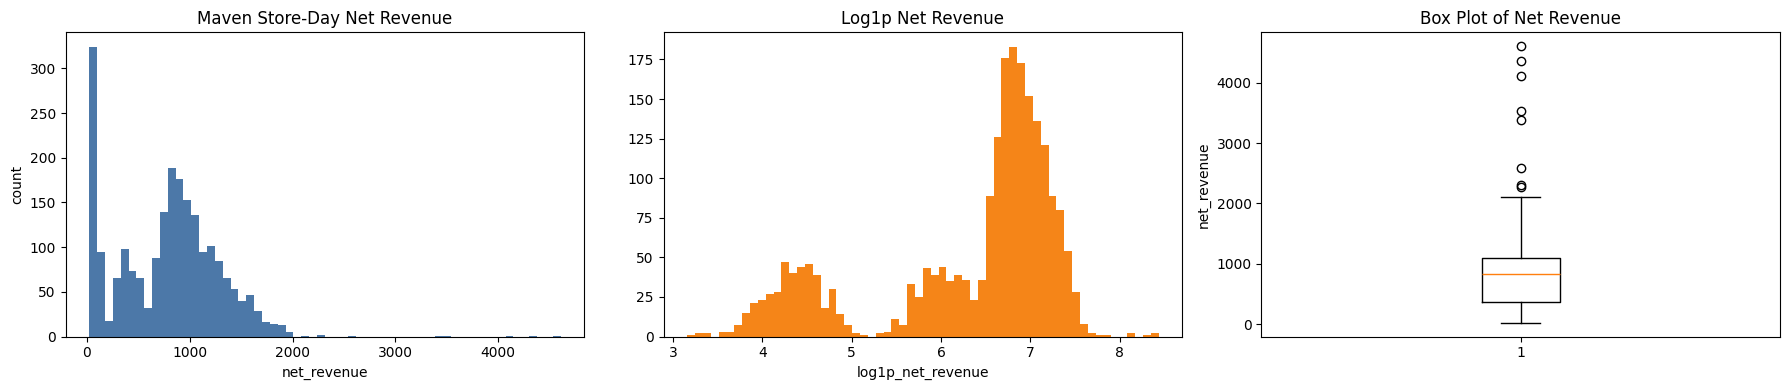

Q1=367.632, Q3=1,103.240, IQR=735.608, upper=2,206.651, outlier_pct=0.36%


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(maven_store_daily["net_revenue"], bins=60, color="#4C78A8")
axes[0].set_title("Maven Store-Day Net Revenue")
axes[0].set_xlabel("net_revenue")
axes[0].set_ylabel("count")

axes[1].hist(maven_store_daily["log1p_net_revenue"], bins=60, color="#F58518")
axes[1].set_title("Log1p Net Revenue")
axes[1].set_xlabel("log1p_net_revenue")

axes[2].boxplot(maven_store_daily["net_revenue"], vert=True)
axes[2].set_title("Box Plot of Net Revenue")
axes[2].set_ylabel("net_revenue")

plt.tight_layout()
plt.show()

q1 = maven_store_daily["net_revenue"].quantile(0.25)
q3 = maven_store_daily["net_revenue"].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
outlier_pct = maven_store_daily["net_revenue"].gt(upper_bound).mean() * 100
print(f"Q1={q1:,.3f}, Q3={q3:,.3f}, IQR={iqr:,.3f}, upper={upper_bound:,.3f}, outlier_pct={outlier_pct:.2f}%")

## Cell 16 - Phân tích theo country, store type và store

Cell này kiểm tra location/store effect. Đây là phần quan trọng nếu muốn gộp nhiều dataset theo scope retail revenue.

,store_country,stores,rows,total_net_revenue,mean_net_revenue,median_net_revenue,zero_sales_pct,return_value,revenue_share_pct,return_rate_pct
2,USA,13,1560,"1,166,577.900",747.806,823.780,0.000,"11,378.540",66.772,0.975
1,Mexico,9,540,"473,993.170",877.765,897.280,0.000,"4,922.490",27.130,1.039
0,Canada,2,120,"106,542.970",887.858,742.325,0.000,"1,131.370",6.098,1.062


,store_type,stores,total_net_revenue,mean_net_revenue,median_net_revenue,mean_total_sqft,mean_grocery_sqft_ratio,revenue_share_pct
4,Supermarket,8,"781,765.620",930.673,890.640,"27,380.000",0.684,44.746
0,Deluxe Supermarket,6,"662,881.220","1,381.003","1,325.970","30,039.250",0.689,37.941
1,Gourmet Supermarket,2,"151,499.150",841.662,847.940,"23,711.667",0.668,8.671
2,Mid-Size Grocery,4,"117,263.930",390.880,383.125,"33,541.400",0.705,6.712
3,Small Grocery,4,"33,704.120",80.248,78.380,"28,257.286",0.705,1.929


,store_id,store_name,store_country,store_state,store_type,first_date,last_date,total_net_revenue,mean_net_revenue,median_net_revenue,p95_net_revenue,zero_sales_pct,return_value,revenue_share_pct
0,13,Store 13,USA,OR,Deluxe Supermarket,1997-01-07,1998-12-27,"168,827.290","1,406.894","1,281.020","2,325.695",0.000,"1,571.650",9.663
1,17,Store 17,USA,WA,Deluxe Supermarket,1997-01-11,1998-12-29,"156,088.540","1,300.738","1,255.985","1,696.755",0.000,"1,607.360",8.934
2,15,Store 15,USA,WA,Supermarket,1997-01-05,1998-12-16,"114,844.170",957.035,899.860,"1,428.598",0.000,"1,137.290",6.573
3,11,Store 11,USA,OR,Supermarket,1997-01-02,1998-12-30,"114,144.890",951.207,928.735,"1,317.957",0.000,"1,189.730",6.533
4,24,Store 24,USA,CA,Supermarket,1997-01-06,1998-12-25,"110,279.590",918.997,886.475,"1,288.736",0.000,"1,098.870",6.312
5,7,Store 7,USA,CA,Supermarket,1997-01-03,1998-12-20,"110,256.700",918.806,858.275,"1,314.727",0.000,"1,054.840",6.311
6,3,Store 3,USA,WA,Supermarket,1997-01-06,1998-12-25,"109,787.870",914.899,881.825,"1,271.938",0.000,"1,090.010",6.284
7,16,Store 16,USA,WA,Supermarket,1997-01-13,1998-12-27,"109,324.020",911.034,872.275,"1,267.086",0.000,"1,161.140",6.257
8,6,Store 6,USA,CA,Gourmet Supermarket,1997-01-01,1998-12-28,"97,169.960",809.750,816.305,"1,121.259",0.000,944.820,5.562
9,12,Store 12,Mexico,Zacatecas,Deluxe Supermarket,1998-01-05,1998-12-26,"86,676.090","1,444.601","1,444.600","1,869.696",0.000,947.520,4.961


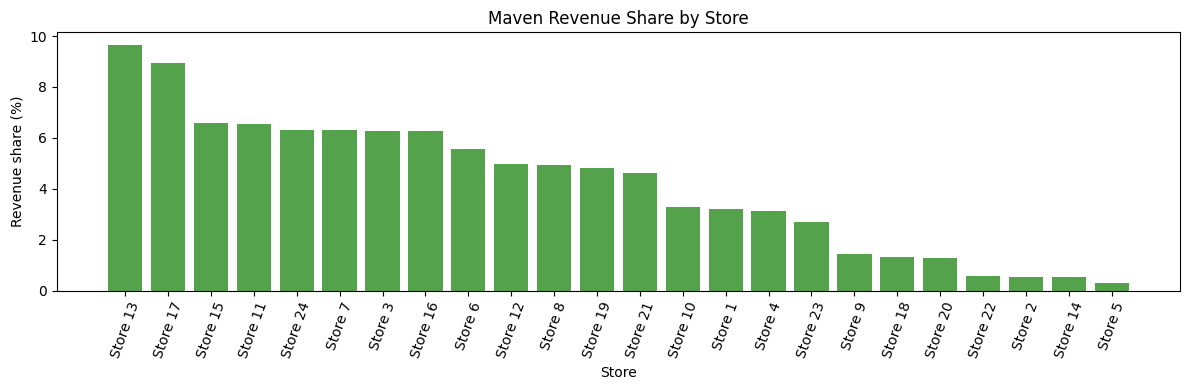

In [16]:
country_summary = (
    maven_store_daily.groupby("store_country", as_index=False)
    .agg(
        stores=("store_id", "nunique"),
        rows=("net_revenue", "size"),
        total_net_revenue=("net_revenue", "sum"),
        mean_net_revenue=("net_revenue", "mean"),
        median_net_revenue=("net_revenue", "median"),
        zero_sales_pct=("gross_revenue", lambda s: s.eq(0).mean() * 100),
        return_value=("return_value", "sum"),
    )
)
country_summary["revenue_share_pct"] = country_summary["total_net_revenue"] / country_summary["total_net_revenue"].sum() * 100
country_summary["return_rate_pct"] = country_summary["return_value"] / country_summary["total_net_revenue"].replace(0, np.nan) * 100
country_summary = country_summary.sort_values("total_net_revenue", ascending=False)

display(country_summary)

store_type_summary = (
    maven_store_daily.groupby("store_type", as_index=False)
    .agg(
        stores=("store_id", "nunique"),
        total_net_revenue=("net_revenue", "sum"),
        mean_net_revenue=("net_revenue", "mean"),
        median_net_revenue=("net_revenue", "median"),
        mean_total_sqft=("total_sqft", "mean"),
        mean_grocery_sqft_ratio=("grocery_sqft_ratio", "mean"),
    )
)
store_type_summary["revenue_share_pct"] = store_type_summary["total_net_revenue"] / store_type_summary["total_net_revenue"].sum() * 100
store_type_summary = store_type_summary.sort_values("total_net_revenue", ascending=False)

display(store_type_summary)

store_summary = (
    maven_store_daily.groupby(["store_id", "store_name", "store_country", "store_state", "store_type"], as_index=False)
    .agg(
        first_date=("date", "min"),
        last_date=("date", "max"),
        total_net_revenue=("net_revenue", "sum"),
        mean_net_revenue=("net_revenue", "mean"),
        median_net_revenue=("net_revenue", "median"),
        p95_net_revenue=("net_revenue", lambda s: s.quantile(0.95)),
        zero_sales_pct=("gross_revenue", lambda s: s.eq(0).mean() * 100),
        return_value=("return_value", "sum"),
    )
)
store_summary["revenue_share_pct"] = store_summary["total_net_revenue"] / store_summary["total_net_revenue"].sum() * 100
store_summary = store_summary.sort_values("total_net_revenue", ascending=False).reset_index(drop=True)

display(store_summary.head(15))

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(store_summary["store_name"], store_summary["revenue_share_pct"], color="#54A24B")
ax.set_title("Maven Revenue Share by Store")
ax.set_xlabel("Store")
ax.set_ylabel("Revenue share (%)")
ax.tick_params(axis="x", rotation=70)
plt.tight_layout()
plt.show()

## Cell 17 - Trend doanh thu theo thời gian

Cell này aggregate toàn chuỗi theo ngày để xem trend 1997-1998.

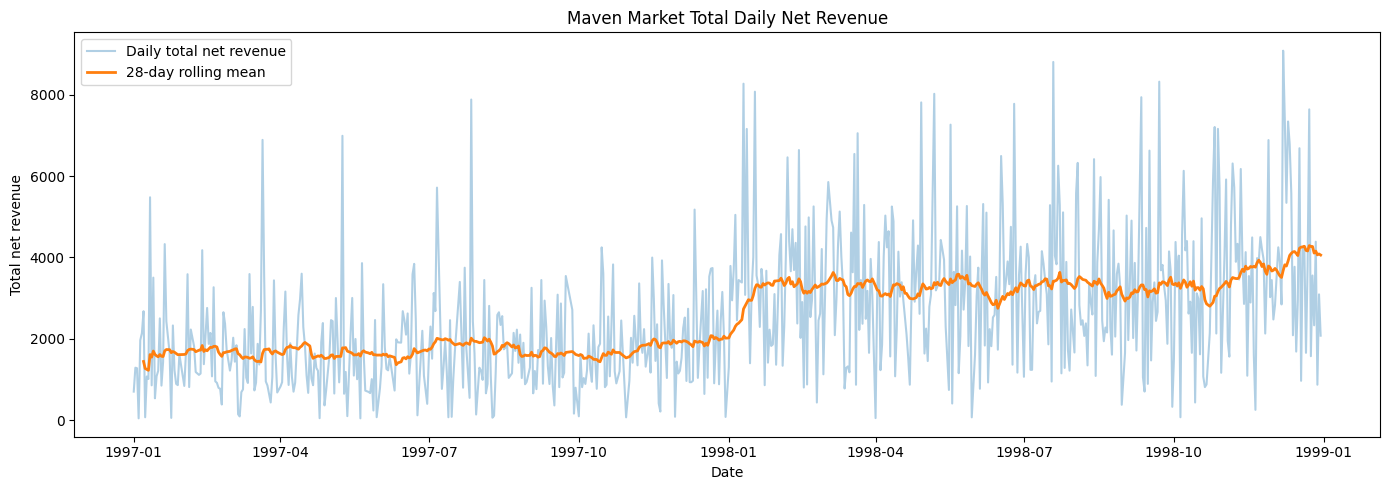

,date,total_gross_revenue,total_return_value,total_net_revenue,active_store_count,rolling_28d_net_revenue
count,673,673.000,673.000,673.000,673.000,667.000
mean,1998-01-07 02:23:21.485884,"2,621.912",25.903,"2,596.009",3.299,"2,565.471"
min,1997-01-01 00:00:00,42.870,0.000,42.870,1.000,"1,224.312"
25%,1997-07-06 00:00:00,"1,214.990",10.850,"1,202.530",2.000,"1,702.039"
50%,1998-01-15 00:00:00,"2,300.910",20.940,"2,285.750",3.000,"2,879.414"
75%,1998-07-10 00:00:00,"3,623.810",36.040,"3,587.900",4.000,"3,338.849"
max,1998-12-30 00:00:00,"9,189.000",113.180,"9,086.190",11.000,"4,291.706"
std,NaN,"1,754.989",19.925,"1,737.282",1.785,853.704


In [17]:
maven_total_daily = (
    maven_store_daily.groupby("date", as_index=False)
    .agg(
        total_gross_revenue=("gross_revenue", "sum"),
        total_return_value=("return_value", "sum"),
        total_net_revenue=("net_revenue", "sum"),
        active_store_count=("has_sales", "sum"),
    )
    .sort_values("date")
)
maven_total_daily["rolling_28d_net_revenue"] = maven_total_daily["total_net_revenue"].rolling(28, min_periods=7).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(maven_total_daily["date"], maven_total_daily["total_net_revenue"], alpha=0.35, label="Daily total net revenue")
ax.plot(maven_total_daily["date"], maven_total_daily["rolling_28d_net_revenue"], linewidth=2, label="28-day rolling mean")
ax.set_title("Maven Market Total Daily Net Revenue")
ax.set_xlabel("Date")
ax.set_ylabel("Total net revenue")
ax.legend()
plt.tight_layout()
plt.show()

display(maven_total_daily.describe())

## Cell 18 - Weekday và month effect

Cell này kiểm tra variation theo thứ trong tuần và tháng.

,day_of_week,day_of_week_num,mean_net_revenue,median_net_revenue,total_net_revenue,rows
1,Monday,0,809.043,852.895,"262,129.830",324
5,Tuesday,1,726.754,789.620,"231,834.520",319
6,Wednesday,2,775.612,842.010,"249,746.960",322
4,Thursday,3,786.441,825.290,"263,457.870",335
0,Friday,4,798.551,834.540,"242,759.460",304
2,Saturday,5,812.514,857.570,"247,816.710",305
3,Sunday,6,801.829,829.370,"249,368.690",311


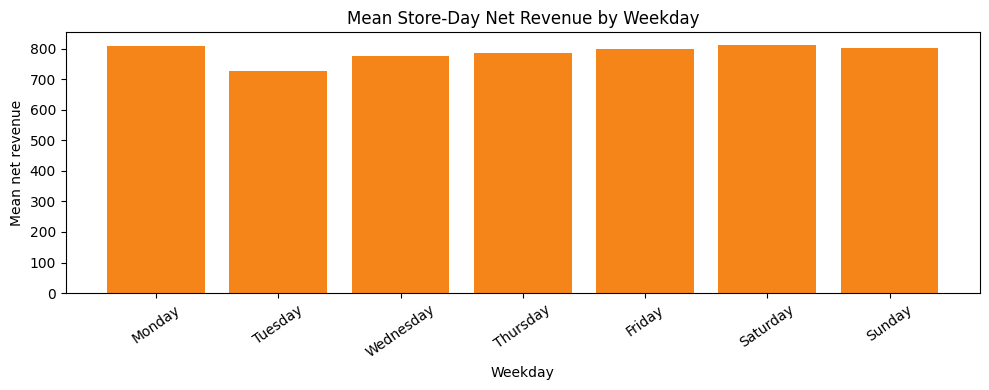

,month,mean_net_revenue,median_net_revenue,total_net_revenue
0,1,768.719,839.250,"142,212.980"
1,2,741.442,837.560,"137,166.710"
2,3,793.362,837.780,"146,772.020"
3,4,737.000,811.010,"136,344.930"
4,5,747.677,755.650,"138,320.200"
5,6,761.868,787.370,"140,945.560"
6,7,798.462,803.940,"147,715.560"
7,8,754.702,867.980,"139,619.800"
8,9,777.399,807.780,"143,818.730"
9,10,720.798,807.890,"133,347.700"


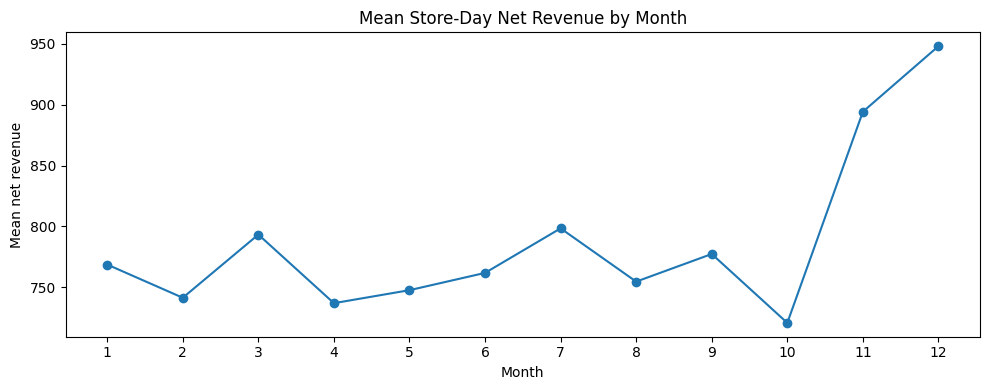

In [18]:
weekday_summary = (
    maven_store_daily.groupby(["day_of_week", "day_of_week_num"], as_index=False)
    .agg(
        mean_net_revenue=("net_revenue", "mean"),
        median_net_revenue=("net_revenue", "median"),
        total_net_revenue=("net_revenue", "sum"),
        rows=("net_revenue", "size"),
    )
    .sort_values("day_of_week_num")
)

display(weekday_summary)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(weekday_summary["day_of_week"], weekday_summary["mean_net_revenue"], color="#F58518")
ax.set_title("Mean Store-Day Net Revenue by Weekday")
ax.set_xlabel("Weekday")
ax.set_ylabel("Mean net revenue")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

month_summary = (
    maven_store_daily.groupby("month", as_index=False)
    .agg(
        mean_net_revenue=("net_revenue", "mean"),
        median_net_revenue=("net_revenue", "median"),
        total_net_revenue=("net_revenue", "sum"),
    )
)
display(month_summary)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(month_summary["month"], month_summary["mean_net_revenue"], marker="o")
ax.set_title("Mean Store-Day Net Revenue by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Mean net revenue")
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

## Cell 19 - Returns analysis

Returns là yếu tố làm giảm net revenue. Cell này xem returns lớn hay nhỏ và tập trung ở store/country nào.

,store_country,store_id,store_name,gross_revenue,return_value,return_quantity,return_days,observed_days,return_rate_pct,return_day_pct
5,Mexico,8,Store 8,"87,253.650","1,072.010",480.000,59,60,1.229,98.333
9,Mexico,18,Store 18,"23,173.910",258.640,112.000,48,60,1.116,80.000
22,USA,23,Store 23,"47,576.780",522.830,250.000,100,120,1.099,83.333
1,Canada,20,Store 20,"22,412.030",246.030,121.000,46,60,1.098,76.667
8,Mexico,12,Store 12,"87,623.610",947.520,460.000,60,60,1.081,100.000
19,USA,16,Store 16,"110,485.160","1,161.140",559.000,116,120,1.051,96.667
0,Canada,19,Store 19,"85,262.310",885.340,420.000,60,60,1.038,100.000
15,USA,11,Store 11,"115,334.620","1,189.730",564.000,116,120,1.032,96.667
2,Mexico,1,Store 1,"56,396.780",576.970,267.000,55,60,1.023,91.667
20,USA,17,Store 17,"157,695.900","1,607.360",764.000,120,120,1.019,100.000


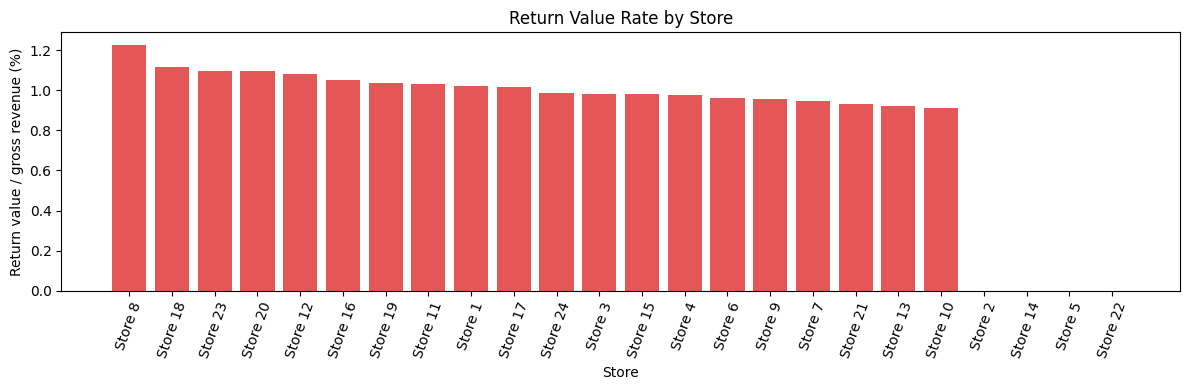

In [19]:
return_store_summary = (
    maven_store_daily.groupby(["store_country", "store_id", "store_name"], as_index=False)
    .agg(
        gross_revenue=("gross_revenue", "sum"),
        return_value=("return_value", "sum"),
        return_quantity=("return_quantity", "sum"),
        return_days=("has_returns", "sum"),
        observed_days=("date", "nunique"),
    )
)
return_store_summary["return_rate_pct"] = return_store_summary["return_value"] / return_store_summary["gross_revenue"].replace(0, np.nan) * 100
return_store_summary["return_day_pct"] = return_store_summary["return_days"] / return_store_summary["observed_days"] * 100
return_store_summary = return_store_summary.sort_values("return_rate_pct", ascending=False)

display(return_store_summary.head(15))

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(return_store_summary["store_name"], return_store_summary["return_rate_pct"], color="#E45756")
ax.set_title("Return Value Rate by Store")
ax.set_xlabel("Store")
ax.set_ylabel("Return value / gross revenue (%)")
ax.tick_params(axis="x", rotation=70)
plt.tight_layout()
plt.show()

## Cell 20 - Product/brand analysis

Maven không có `dept_id` giống M5. Biến gần nhất để phân tích nhóm sản phẩm là `product_brand`, nhưng cần ghi rõ brand không tương đương department/category.

store_brand_daily_nonzero shape: (117043, 10)


,product_brand,rows,total_net_revenue,mean_net_revenue,median_net_revenue,total_quantity,product_count,return_value,revenue_share_pct
0,Hermanos,1944,"56,025.780",28.820,25.655,24682,20,633.700,3.207
1,Tell Tale,1910,"51,045.740",26.726,23.450,23801,19,515.480,2.922
2,Ebony,1901,"49,249.820",25.907,22.310,23492,20,477.640,2.819
3,Tri-State,1868,"48,862.640",26.158,22.350,23400,19,485.110,2.797
4,High Top,1922,"46,731.540",24.314,21.605,22040,20,468.990,2.675
5,Nationeel,1848,"44,869.550",24.280,21.115,19959,13,515.270,2.568
6,Horatio,1818,"43,236.290",23.782,20.965,19205,13,551.460,2.475
7,Best Choice,1828,"42,371.500",23.179,19.440,18553,15,366.520,2.425
8,Fast,1850,"40,093.580",21.672,18.850,19118,16,439.260,2.295
9,Fort West,1833,"39,706.670",21.662,19.020,18869,12,354.360,2.273


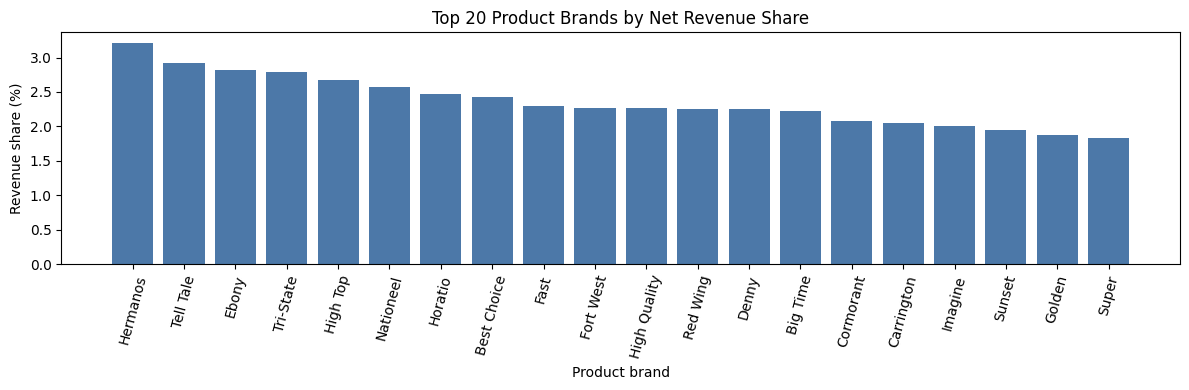

In [20]:
sales_brand_daily = (
    line_items.groupby(["transaction_date", "store_id", "product_brand"], as_index=False)
    .agg(
        gross_revenue=("gross_revenue", "sum"),
        quantity_sold=("quantity", "sum"),
        product_count=("product_id", "nunique"),
        line_item_count=("product_id", "size"),
    )
    .rename(columns={"transaction_date": "date"})
)

returns_brand_daily = (
    returns.groupby(["return_date", "store_id", "product_brand"], as_index=False)
    .agg(
        return_value=("return_value", "sum"),
        return_quantity=("quantity", "sum"),
    )
    .rename(columns={"return_date": "date"})
)

store_brand_daily_nonzero = sales_brand_daily.merge(
    returns_brand_daily,
    on=["date", "store_id", "product_brand"],
    how="left",
    validate="one_to_one",
)
store_brand_daily_nonzero[["return_value", "return_quantity"]] = store_brand_daily_nonzero[["return_value", "return_quantity"]].fillna(0)
store_brand_daily_nonzero["net_revenue"] = store_brand_daily_nonzero["gross_revenue"] - store_brand_daily_nonzero["return_value"]

brand_summary = (
    store_brand_daily_nonzero.groupby("product_brand", as_index=False)
    .agg(
        rows=("net_revenue", "size"),
        total_net_revenue=("net_revenue", "sum"),
        mean_net_revenue=("net_revenue", "mean"),
        median_net_revenue=("net_revenue", "median"),
        total_quantity=("quantity_sold", "sum"),
        product_count=("product_count", "max"),
        return_value=("return_value", "sum"),
    )
)
brand_summary["revenue_share_pct"] = brand_summary["total_net_revenue"] / brand_summary["total_net_revenue"].sum() * 100
brand_summary = brand_summary.sort_values("total_net_revenue", ascending=False).reset_index(drop=True)

print("store_brand_daily_nonzero shape:", store_brand_daily_nonzero.shape)
display(brand_summary.head(20))

fig, ax = plt.subplots(figsize=(12, 4))
top20 = brand_summary.head(20)
ax.bar(top20["product_brand"], top20["revenue_share_pct"], color="#4C78A8")
ax.set_title("Top 20 Product Brands by Net Revenue Share")
ax.set_xlabel("Product brand")
ax.set_ylabel("Revenue share (%)")
ax.tick_params(axis="x", rotation=75)
plt.tight_layout()
plt.show()

## Cell 21 - Customer mix analysis chỉ để insight

Customer demographics có thể giúp hiểu doanh thu, nhưng nếu bài toán là forecast doanh thu trước ngày bán thì các biến như `distinct_customers`, `avg_customer_age`, member mix là thông tin sau bán hàng, không nên dùng trong baseline model.

In [21]:
customer_country_summary = (
    line_items.groupby("customer_country", as_index=False)
    .agg(
        gross_revenue=("gross_revenue", "sum"),
        quantity=("quantity", "sum"),
        customers=("customer_id", "nunique"),
        line_items=("product_id", "size"),
        avg_customer_age=("customer_age", "mean"),
    )
)
customer_country_summary["revenue_share_pct"] = customer_country_summary["gross_revenue"] / customer_country_summary["gross_revenue"].sum() * 100
customer_country_summary = customer_country_summary.sort_values("gross_revenue", ascending=False)

display(customer_country_summary)

member_summary = (
    line_items.groupby("member_card", as_index=False)
    .agg(
        gross_revenue=("gross_revenue", "sum"),
        customers=("customer_id", "nunique"),
        line_items=("product_id", "size"),
        avg_quantity=("quantity", "mean"),
    )
)
member_summary["revenue_share_pct"] = member_summary["gross_revenue"] / member_summary["gross_revenue"].sum() * 100
member_summary = member_summary.sort_values("gross_revenue", ascending=False)

display(member_summary)

,customer_country,gross_revenue,quantity,customers,line_items,avg_customer_age,revenue_share_pct
2,USA,"1,177,956.440",555899,6357,180823,52.872,66.757
1,Mexico,"478,915.660",226838,1105,72806,53.414,27.141
0,Canada,"107,674.340",50752,1380,16091,52.973,6.102


,member_card,gross_revenue,customers,line_items,avg_quantity,revenue_share_pct
0,Bronze,"986,502.650",4911,151261,3.075,55.907
2,Normal,"406,875.660",2086,62408,3.081,23.058
1,Golden,"223,670.660",1018,33432,3.178,12.676
3,Silver,"147,497.470",827,22619,3.090,8.359


## Cell 22 - Bootstrapping confidence interval

Áp dụng kiến thức `Bootstrapping`: ước lượng khoảng tin cậy cho mean net revenue store-day.

In [22]:
def bootstrap_mean_ci(values, n_boot=1000, ci=0.95, random_state=42):
    rng = np.random.default_rng(random_state)
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    boot_means = np.empty(n_boot)
    for i in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        boot_means[i] = sample.mean()
    alpha = (1 - ci) / 2
    return values.mean(), np.quantile(boot_means, alpha), np.quantile(boot_means, 1 - alpha)

overall_mean, overall_low, overall_high = bootstrap_mean_ci(maven_store_daily["net_revenue"], n_boot=500)
print(f"Overall mean net revenue per store-day: {overall_mean:,.3f}")
print(f"95% bootstrap CI: [{overall_low:,.3f}, {overall_high:,.3f}]")

bootstrap_by_country = []
for country, group in maven_store_daily.groupby("store_country"):
    mean_v, low_v, high_v = bootstrap_mean_ci(group["net_revenue"], n_boot=300, random_state=42)
    bootstrap_by_country.append((country, mean_v, low_v, high_v))

bootstrap_by_country = pd.DataFrame(bootstrap_by_country, columns=["store_country", "mean_net_revenue", "ci95_low", "ci95_high"])
bootstrap_by_country = bootstrap_by_country.sort_values("mean_net_revenue", ascending=False).reset_index(drop=True)
display(bootstrap_by_country)

Overall mean net revenue per store-day: 786.988
95% bootstrap CI: [765.152, 807.483]


,store_country,mean_net_revenue,ci95_low,ci95_high
0,Canada,887.858,797.030,973.527
1,Mexico,877.765,834.796,916.836
2,USA,747.806,721.261,771.004


## Cell 23 - Feature schema và leakage

Cell này chốt cột nào có thể dùng cho baseline model và cột nào chỉ dùng để phân tích. Với target `net_revenue`, rất nhiều biến từ transaction trong cùng ngày là leakage.

In [23]:
feature_decision = pd.DataFrame(
    [
        ("year/month/week/day_of_week/is_weekend", "Dùng", "Biết trước, phản ánh temporal pattern."),
        ("store_id/store_country/store_state/store_type", "Dùng", "Store/location effect biết trước."),
        ("sales_region/sales_district", "Dùng", "Vùng bán hàng biết trước."),
        ("total_sqft/grocery_sqft/grocery_sqft_ratio", "Dùng", "Đặc điểm cửa hàng biết trước."),
        ("store_age_years/days_since_remodel", "Dùng", "Có thể tính từ date và metadata store."),
        ("gross_revenue", "Không dùng", "Gross revenue cùng ngày là thành phần trực tiếp của net revenue."),
        ("return_value", "Không dùng baseline", "Return cùng ngày là hậu nghiệm; chỉ dùng nếu mô hình dự báo sau khi biết returns."),
        ("quantity_sold/line_item_count", "Không dùng", "Thông tin sau bán hàng, leakage mạnh."),
        ("distinct_customers/distinct_products_sold", "Không dùng baseline", "Biết sau khi ngày bán xảy ra."),
        ("avg_customer_age/member mix", "Insight only", "Customer mix trong ngày là hậu bán hàng nếu forecast trước ngày."),
        ("product_brand", "Cẩn thận", "Chỉ dùng nếu target là store-brand-day; không tương đương dept_id của M5."),
        ("log1p_net_revenue", "Target transform", "Không phải feature; dùng nếu train mô hình trên log target."),
    ],
    columns=["field_or_group", "decision", "reason"],
)

display(feature_decision)

safe_features_store_daily = [
    "year", "month", "quarter", "week_of_year", "day_of_month", "day_of_year", "day_of_week_num", "is_weekend",
    "store_id", "store_type", "store_state", "store_country", "sales_district", "sales_region",
    "total_sqft", "grocery_sqft", "grocery_sqft_ratio", "store_age_years", "days_since_remodel",
]

target_col = "net_revenue"
print("Target:", target_col)
print("Safe baseline features for Maven store-day model:")
print(safe_features_store_daily)

,field_or_group,decision,reason
0,year/month/week/day_of_week/is_weekend,Dùng,"Biết trước, phản ánh temporal pattern."
1,store_id/store_country/store_state/store_type,Dùng,Store/location effect biết trước.
2,sales_region/sales_district,Dùng,Vùng bán hàng biết trước.
3,total_sqft/grocery_sqft/grocery_sqft_ratio,Dùng,Đặc điểm cửa hàng biết trước.
4,store_age_years/days_since_remodel,Dùng,Có thể tính từ date và metadata store.
5,gross_revenue,Không dùng,Gross revenue cùng ngày là thành phần trực tiế...
6,return_value,Không dùng baseline,Return cùng ngày là hậu nghiệm; chỉ dùng nếu m...
7,quantity_sold/line_item_count,Không dùng,"Thông tin sau bán hàng, leakage mạnh."
8,distinct_customers/distinct_products_sold,Không dùng baseline,Biết sau khi ngày bán xảy ra.
9,avg_customer_age/member mix,Insight only,Customer mix trong ngày là hậu bán hàng nếu fo...


Target: net_revenue
Safe baseline features for Maven store-day model:
['year', 'month', 'quarter', 'week_of_year', 'day_of_month', 'day_of_year', 'day_of_week_num', 'is_weekend', 'store_id', 'store_type', 'store_state', 'store_country', 'sales_district', 'sales_region', 'total_sqft', 'grocery_sqft', 'grocery_sqft_ratio', 'store_age_years', 'days_since_remodel']


## Cell 24 - Nhận xét Data Science sau khi chạy output

Cell này biến output thành insight để đưa vào báo cáo.

In [24]:
mean_revenue = maven_store_daily["net_revenue"].mean()
median_revenue = maven_store_daily["net_revenue"].median()
mean_median_ratio = mean_revenue / median_revenue if median_revenue else np.nan

q1 = maven_store_daily["net_revenue"].quantile(0.25)
q3 = maven_store_daily["net_revenue"].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
outlier_pct = maven_store_daily["net_revenue"].gt(upper_bound).mean() * 100

if mean_median_ratio > 1.15:
    target_assessment = "Lệch phải"
elif mean_median_ratio < 0.85:
    target_assessment = "Lệch trái nhẹ"
else:
    target_assessment = "Tương đối cân bằng"

top_country = country_summary.iloc[0]
top_store = store_summary.iloc[0]
top_store_type = store_type_summary.iloc[0]
top_brand = brand_summary.iloc[0]
zero_sales_pct = maven_store_daily["gross_revenue"].eq(0).mean() * 100
panel_zero_pct = maven_store_daily_panel["gross_revenue"].eq(0).mean() * 100
return_rate = maven_store_daily["return_value"].sum() / maven_store_daily["gross_revenue"].sum() * 100

weekday_max = weekday_summary.loc[weekday_summary["mean_net_revenue"].idxmax()]
weekday_min = weekday_summary.loc[weekday_summary["mean_net_revenue"].idxmin()]

post_run_findings = pd.DataFrame(
    [
        ("Join quality", "Đạt", f"Line items join không thiếu product/store/customer; bảng chính có {len(maven_store_daily):,} rows ở cấp observed date-store."),
        ("Target", "Net revenue", "net_revenue = gross_revenue - return_value; gross_revenue = quantity * product_retail_price."),
        ("Target distribution", target_assessment, f"Mean/median = {mean_median_ratio:.2f}; high outlier rows theo IQR = {outlier_pct:.2f}%."),
        ("Panel sparsity", "Cần cảnh báo", f"Nếu tạo panel date-store đầy đủ thì zero gross revenue = {panel_zero_pct:.2f}%, nên không dùng panel đó làm bảng chính lúc này."),
        ("Observed table", "Hợp lý hơn cho EDA", f"Bảng chính chỉ gồm store-day có hoạt động quan sát; zero gross revenue = {zero_sales_pct:.2f}%."),
        ("Return impact", "Nhỏ nhưng nên giữ", f"Return value rate toàn dataset khoảng {return_rate:.2f}% gross revenue."),
        ("Country effect", "Rõ", f"Top country {top_country['store_country']} chiếm {top_country['revenue_share_pct']:.2f}% net revenue."),
        ("Store effect", "Rõ", f"Top store {top_store['store_name']} chiếm {top_store['revenue_share_pct']:.2f}% net revenue."),
        ("Store type effect", "Rõ", f"Top store type {top_store_type['store_type']} chiếm {top_store_type['revenue_share_pct']:.2f}% net revenue."),
        ("Weekday effect", "Có tín hiệu", f"Ngày mean cao nhất là {weekday_max['day_of_week']}, thấp nhất là {weekday_min['day_of_week']}."),
        ("Brand effect", "Có nhưng không tương đương M5 dept", f"Top brand {top_brand['product_brand']} chiếm {top_brand['revenue_share_pct']:.2f}% net revenue."),
        ("Modeling warning", "Leakage risk", "Không dùng quantity_sold, line_item_count, distinct_customers, gross_revenue, return_value làm feature baseline."),
    ],
    columns=["aspect", "assessment", "evidence"],
)

display(post_run_findings)

print("Bước tiếp theo nên làm:")
next_steps = [
    "1. Chốt target Maven chính: observed date + store_id -> net_revenue.",
    "2. Dùng store/date metadata làm baseline features, tránh transaction-derived leakage.",
    "3. Báo cáo rõ Maven không phải panel đầy đủ như M5: date-store không xuất hiện nên xem là unobserved, không mặc định bằng 0.",
    "4. Nếu muốn so sánh với M5 ở cấp product group, Maven chỉ có product_brand nên cần ghi rõ không tương đương dept_id.",
    "5. Khi gộp M5 + Maven, nên ưu tiên schema store-day trước: date + store + external/store/time features -> daily revenue.",
]
for step in next_steps:
    print(step)

,aspect,assessment,evidence
0,Join quality,Đạt,Line items join không thiếu product/store/cust...
1,Target,Net revenue,net_revenue = gross_revenue - return_value; gr...
2,Target distribution,Tương đối cân bằng,Mean/median = 0.94; high outlier rows theo IQR...
3,Panel sparsity,Cần cảnh báo,Nếu tạo panel date-store đầy đủ thì zero gross...
4,Observed table,Hợp lý hơn cho EDA,Bảng chính chỉ gồm store-day có hoạt động quan...
5,Return impact,Nhỏ nhưng nên giữ,Return value rate toàn dataset khoảng 0.99% gr...
6,Country effect,Rõ,Top country USA chiếm 66.77% net revenue.
7,Store effect,Rõ,Top store Store 13 chiếm 9.66% net revenue.
8,Store type effect,Rõ,Top store type Supermarket chiếm 44.75% net re...
9,Weekday effect,Có tín hiệu,"Ngày mean cao nhất là Saturday, thấp nhất là T..."


Bước tiếp theo nên làm:
1. Chốt target Maven chính: observed date + store_id -> net_revenue.
2. Dùng store/date metadata làm baseline features, tránh transaction-derived leakage.
3. Báo cáo rõ Maven không phải panel đầy đủ như M5: date-store không xuất hiện nên xem là unobserved, không mặc định bằng 0.
4. Nếu muốn so sánh với M5 ở cấp product group, Maven chỉ có product_brand nên cần ghi rõ không tương đương dept_id.
5. Khi gộp M5 + Maven, nên ưu tiên schema store-day trước: date + store + external/store/time features -> daily revenue.


## Cell 25 - Optional export

Cell này chưa tự động lưu CSV để bạn đọc output trước. Khi muốn lưu bảng clean, đổi `EXPORT_CSV = True`.

In [25]:
EXPORT_CSV = False
OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "maven_store_daily_clean.csv"

if EXPORT_CSV:
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    maven_store_daily.to_csv(OUTPUT_PATH, index=False, encoding="utf-8")
    print("Saved to:", OUTPUT_PATH)
else:
    print("EXPORT_CSV = False, chưa lưu CSV.")
    print("Nếu muốn lưu, đổi EXPORT_CSV = True rồi chạy lại cell này.")

EXPORT_CSV = False, chưa lưu CSV.
Nếu muốn lưu, đổi EXPORT_CSV = True rồi chạy lại cell này.
